In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [6]:
import os

# Define a quantidade máxima de núcleos para o Loky (ex: quantidade de núcleos do sistema)
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 4)


In [3]:
matriz_pan_antes_imputação = pd.read_csv(r"C:\Users\Leticia\Downloads\matriz_reduzida_sweepREF.txt", sep="\t")
matriz_pan_apos_imputacao = pd.read_csv(r"C:\Users\Leticia\Downloads\sweep_alvo_pos_imputacao.txt", sep="\t")
rotulos_pan = pd.read_csv(r'C:\Users\Leticia\Documents\Letworkspace\Treinamento-MLP-Mathys\Inputs\rotulos\PanNumerico.csv')

In [4]:
X  = matriz_pan_antes_imputação### passagem dos dados para  variavel
y = rotulos_pan
 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


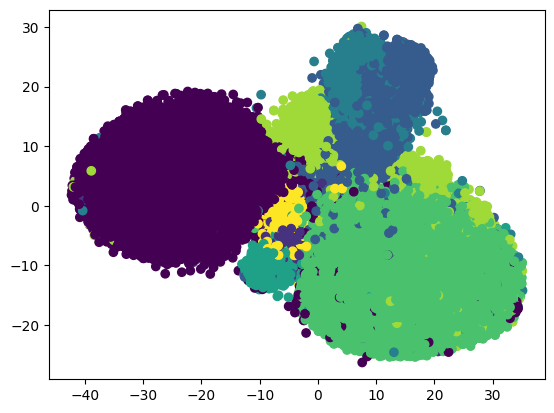

In [9]:
# Opção 1: Se y for um DataFrame do pandas e os valores puderem ser convertidos para int/float
c_values = y.iloc[:, 0].astype(int)
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=c_values, cmap="viridis")


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not        6
0      6
1      6
2      1
3      6
4      6
...   ..
58320  7
58321  6
58322  1
58323  6
58324  1

[58325 rows x 1 columns]

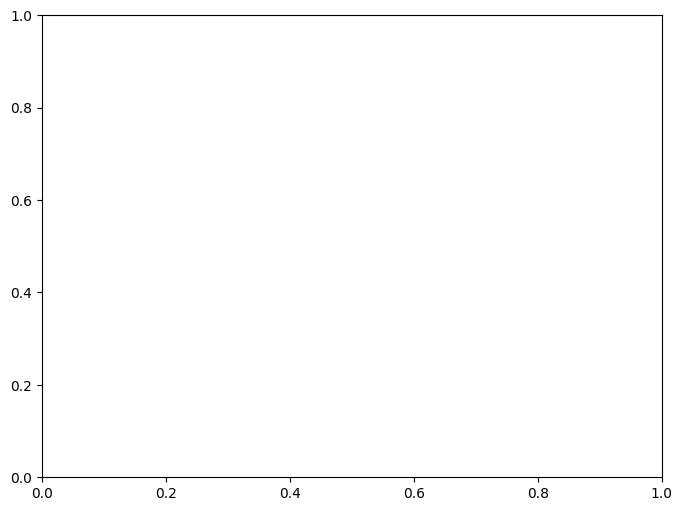

In [8]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)

# 5. Plotar
plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap="viridis")
plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.show()

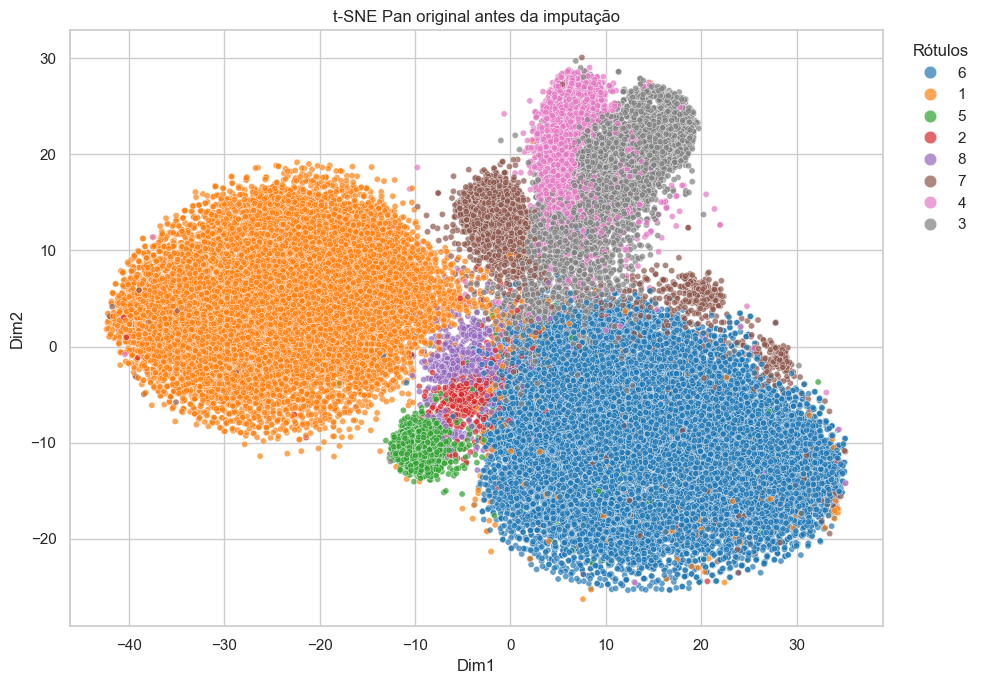

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_tsne = pd.DataFrame(
    {
        "Dim1": X_embedded[:, 0],
        "Dim2": X_embedded[:, 1],
        "Classe": y.iloc[:, 0].astype(str),  # Converte para texto para virar categoria
    }
)

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_tsne,
    x="Dim1",
    y="Dim2",
    hue="Classe",
    palette="tab10",  # Atribui automaticamente uma cor distinta para cada número
    alpha=0.7,
    s=20,
)

plt.legend(
    title="Rótulos",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    markerscale=2,  # Bolinhas da legenda maiores
)
plt.title("t-SNE Pan original antes da imputação")
plt.tight_layout()
plt.show()
